# Task 4

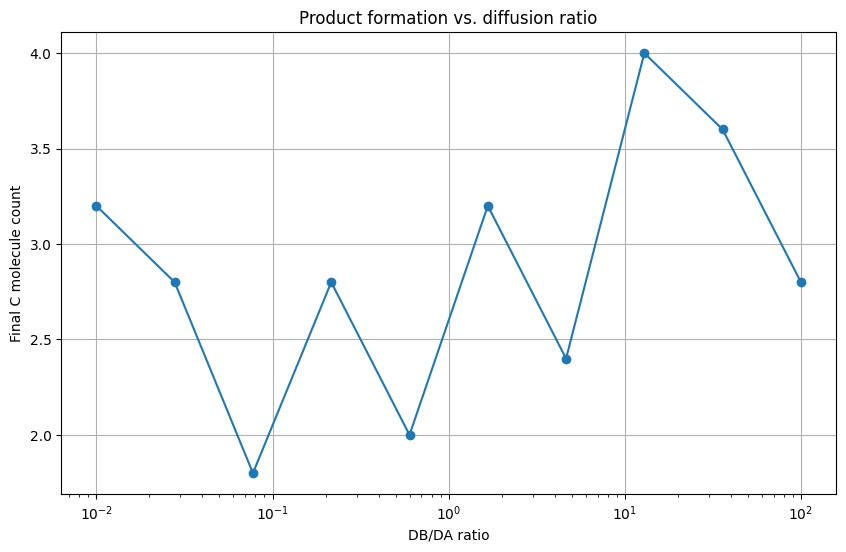

In [2]:
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt
from typing import Tuple, List

@dataclass
class SimulationParams:
    L: int  # Grid size
    F: float  # Deposition flux (layer/s)
    DA: float  # Diffusion coefficient for A (s^-1)
    DB: float  # Diffusion coefficient for B (s^-1)
    DC: float  # Diffusion coefficient for C (s^-1)
    dt: float  # Time step
    total_time: float  # Total simulation time
    n_independent: int  # Number of independent runs

class SurfaceReactionSimulation:
    def __init__(self, params: SimulationParams):
        self.params = params
        self.grid = np.zeros((params.L, params.L), dtype=str)  # Empty grid
        self.molecules = {'A': [], 'B': [], 'C': []}  # Track molecule positions
        self.islands = []  # Track island positions
        
    def deposit_molecule(self, species: str) -> bool:
        """Try to deposit a molecule of given species at random position"""
        x, y = np.random.randint(0, self.params.L, 2)
        if self.grid[x, y] == '':
            self.grid[x, y] = species
            self.molecules[species].append((x, y))
            return True
        return False
    
    def try_diffuse(self, species: str, pos: Tuple[int, int]) -> bool:
        """Attempt to diffuse a molecule to adjacent site"""
        x, y = pos
        # Possible moves: up, down, left, right
        moves = [(x+1, y), (x-1, y), (x, y+1), (x, y-1)]
        np.random.shuffle(moves)
        
        for new_x, new_y in moves:
            if (0 <= new_x < self.params.L and 
                0 <= new_y < self.params.L and 
                self.grid[new_x, new_y] == ''):
                # Move molecule
                self.grid[x, y] = ''
                self.grid[new_x, new_y] = species
                self.molecules[species].remove((x, y))
                self.molecules[species].append((new_x, new_y))
                return True
        return False
    
    def check_reactions(self) -> None:
        """Check for possible reactions between adjacent molecules"""
        reactions_to_process = []
        
        # Check for A-B reactions to form C
        for a_pos in self.molecules['A']:
            x, y = a_pos
            adjacent = [(x+1, y), (x-1, y), (x, y+1), (x, y-1)]
            
            for adj_x, adj_y in adjacent:
                if (0 <= adj_x < self.params.L and 
                    0 <= adj_y < self.params.L):
                    if self.grid[adj_x, adj_y] == 'B':
                        reactions_to_process.append((
                            (x, y), 
                            (adj_x, adj_y)
                        ))
        
        # Process reactions
        for (a_pos, b_pos) in reactions_to_process:
            # Remove reactants
            self.grid[a_pos] = ''
            self.grid[b_pos] = ''
            self.molecules['A'].remove(a_pos)
            self.molecules['B'].remove(b_pos)
            
            # Add product C at average position
            c_pos = (
                (a_pos[0] + b_pos[0]) // 2,
                (a_pos[1] + b_pos[1]) // 2
            )
            self.grid[c_pos] = 'C'
            self.molecules['C'].append(c_pos)
    
    def run_simulation(self) -> dict:
        """Run full simulation and return results"""
        time = 0
        results = {
            'time': [],
            'A_count': [],
            'B_count': [],
            'C_count': [],
            'island_count': []
        }
        
        while time < self.params.total_time:
            # Deposition step
            if np.random.random() < self.params.F * self.params.dt:
                species = np.random.choice(['A', 'B'])
                self.deposit_molecule(species)
            
            # Diffusion steps
            for species, D in [
                ('A', self.params.DA),
                ('B', self.params.DB),
                ('C', self.params.DC)
            ]:
                n_attempts = int(D * self.params.dt)
                for _ in range(n_attempts):
                    if self.molecules[species]:
                        mol_pos = self.molecules[species][
                            np.random.randint(len(self.molecules[species]))
                        ]
                        self.try_diffuse(species, mol_pos)
            
            # Reaction step
            self.check_reactions()
            
            # Record results
            results['time'].append(time)
            results['A_count'].append(len(self.molecules['A']))
            results['B_count'].append(len(self.molecules['B']))
            results['C_count'].append(len(self.molecules['C']))
            results['island_count'].append(len(self.islands))
            
            time += self.params.dt
            
        return results

def run_parameter_study(
    DB_DA_ratios: List[float],
    base_params: SimulationParams
) -> dict:
    """Run simulations for different DB/DA ratios"""
    results = {}
    
    for ratio in DB_DA_ratios:
        params = SimulationParams(
            **base_params.__dict__
        )
        params.DB = params.DA * ratio
        
        # Run multiple independent simulations
        c_counts = []
        for _ in range(params.n_independent):
            sim = SurfaceReactionSimulation(params)
            sim_results = sim.run_simulation()
            c_counts.append(sim_results['C_count'][-1])
        
        results[ratio] = {
            'mean_C': np.mean(c_counts),
            'std_C': np.std(c_counts)
        }
    
    return results

# Run a parameter study
base_params = SimulationParams(
    L=100,  # Grid size
    F=1.0,  # 1 layer/s deposition rate
    DA=1e4,  # Fixed diffusion coefficient for A
    DB=1e4,  # Will be varied relative to DA
    DC=10,  # Fixed low diffusion coefficient for C
    dt=1e-4,  # Time step
    total_time=10,  # Total simulation time
    n_independent=5  # Number of independent runs
)

#DB_DA_ratios = [0.01, 0.1, 0.5, 1.0]
DB_DA_ratios = np.logspace(-2, 2, num=10)
study_results = run_parameter_study(DB_DA_ratios, base_params)

# Plot results
plt.figure(figsize=(10, 6))
ratios = list(study_results.keys())
means = [r['mean_C'] for r in study_results.values()]
stds = [r['std_C'] for r in study_results.values()]

#plt.errorbar(ratios, means, yerr=stds, marker='o')
plt.plot(ratios, means, marker='o')
plt.xscale('log')
plt.xlabel('DB/DA ratio')
plt.ylabel('Final C molecule count')
plt.title('Product formation vs. diffusion ratio')
plt.grid(True)